<h2> Лабораторна робота №3 “Кластеризація” </h2>

<h3>1. Завантаження та підготовка даних</h3>
<ol>
    <li>Завантажити набір даних.</li>
    <li>Вивести перші кілька рядків і статистики колонок.</li>
    <li>Виконати стандартизацію числових ознак.</li>
    <li>Для зменшення кількості точок у візуалізації залишити лише треки з popularity ≥ 85. (Решту треків можна використати для навчання моделі, але візуалізувати лише популярні.).</li>
    <li>Вивести розмірність таблиці після фільтрації.</li>

</ol>

In [42]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [22]:
path = kagglehub.dataset_download("zaheenhamidani/ultimate-spotify-tracks-db")
print("Файли завантажено у:", path)
files = os.listdir(path)
print("Список файлів у папці:", files)

csv_file_name = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_path)
print(f"Розмірність таблиці: {df.shape}")
df.head()

Файли завантажено у: C:\Users\Acer\.cache\kagglehub\datasets\zaheenhamidani\ultimate-spotify-tracks-db\versions\3
Список файлів у папці: ['SpotifyFeatures.csv']
Розмірність таблиці: (232725, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [21]:
scaler = StandardScaler()
colsToScale = ['danceability', 'energy', 'loudness', 'speechiness', 
                 'acousticness', 'instrumentalness', 'liveness', 
                 'valence', 'tempo', 'duration_ms']
df[colsToScale] = scaler.fit_transform(df[colsToScale])

df_popular = df[df['popularity'] >= 85].copy()
print(f"Розмірність таблиці: {df_popular.shape}")
df_popular.head()

Розмірність таблиці: (417, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,-0.920210,0.924721,-0.375685,-0.064366,-0.489819,F,-0.549796,0.713529,Minor,-0.156670,1.693669,4/4,-0.461104
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.590358,0.919334,-0.474898,-0.948768,-0.489819,C#,-0.638563,-0.195745,Minor,1.090110,-1.538070,4/4,-0.522627
9028,Dance,Halsey,Without Me,5p7ujcrUXASCNwRaWNHR1C,97,-0.201711,1.064802,-0.281340,-0.314884,-0.489788,F#,-0.612337,0.420108,Major,-0.270944,0.594664,4/4,0.300245
9029,Dance,Ariana Grande,needy,1TEL6MlSSVLSdhOSddidlJ,92,1.159745,0.499093,-0.534317,-0.994317,-0.489794,G,-0.065613,0.270396,Minor,-0.453676,-0.991027,4/4,-0.999431
9030,Dance,Ariana Grande,NASA,4uTvPEr01pjTbZgl7jcKBD,91,0.232376,1.037863,-0.446648,-0.428755,-0.489819,F#,0.186565,0.446616,Major,0.982304,-1.379909,4/4,0.057998


<h3>2. Підбір оптимальної кількості кластерів (k) — метод ліктя</h3>
<ol>
    <li>Ініціалізувати модель KMeans із різною кількістю кластерів (наприклад k = 2…15).</li>
    <li>Для кожного k обчислити інерцію (суму квадратів відстаней до центрів кластерів).</li>
    <li>Побудувати графік залежності інерції від k.</li>
    <li>Визначити оптимальне k.</li>
</ol>

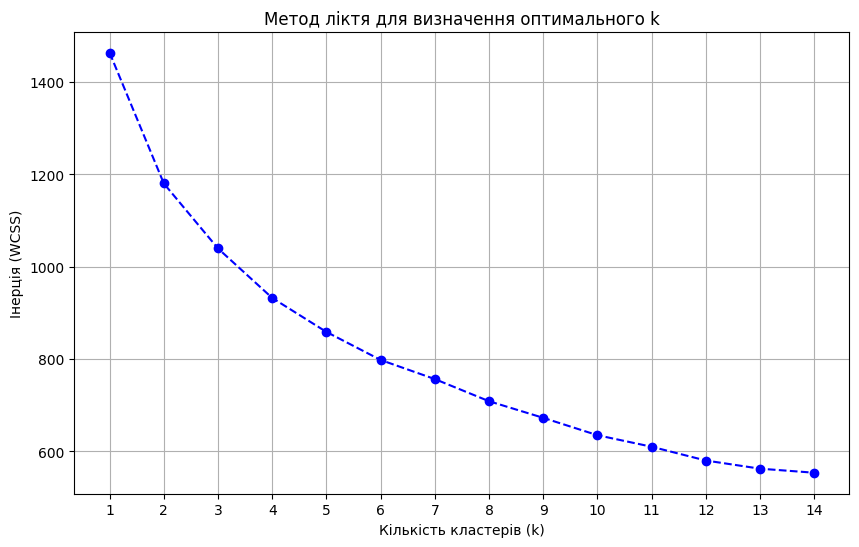

In [32]:
X = df_popular[colsToScale]

inertia = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Метод ліктя для визначення оптимального k')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Інерція (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

<h3>3. Побудова кластеризації</h3>
<ol>
    <li>Виконати кластеризацію з обраним значенням k.</li>
    <li>Додати отримані мітки кластерів до DataFrame як нову колонку cluster.</li>
    <li>Вивести кількість треків у кожному кластері.</li>
</ol>

In [33]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

df_popular['cluster'] = kmeans.fit_predict(X)
cluster_counts = df_popular['cluster'].value_counts().sort_index()
print(f"Кількість треків у кожному кластері: {cluster_counts}")

print("Приклади пісень по кластерах:")
df_popular[['artist_name', 'track_name', 'cluster']].head(10)

Кількість треків у кожному кластері: cluster
0     75
1     72
2    130
3     92
4     48
Name: count, dtype: int64
Приклади пісень по кластерах:


,artist_name,track_name,cluster
9026,Ariana Grande,"break up with your girlfriend, i'm bored",3
9027,Ariana Grande,7 rings,4
9028,Halsey,Without Me,0
9029,Ariana Grande,needy,4
9030,Ariana Grande,NASA,4
9031,Ariana Grande,"thank u, next",2
9032,Ariana Grande,bloodline,0
9033,Ariana Grande,bad idea,0
9034,benny blanco,Eastside (with Halsey & Khalid),4
9035,Ariana Grande,fake smile,4


<h3>4. Візуалізація кластерів у просторі головних компонент</h3>
<ol>
    <li>Виконати PCA до двох/трьох компонент для візуалізації.</li>
    <li>Побудувати 2D/3D-графік з кольором точок за значенням cluster. Для покращення читабельності візуалізувати лише треки з popularity ≥ 85.</li>
</ol>

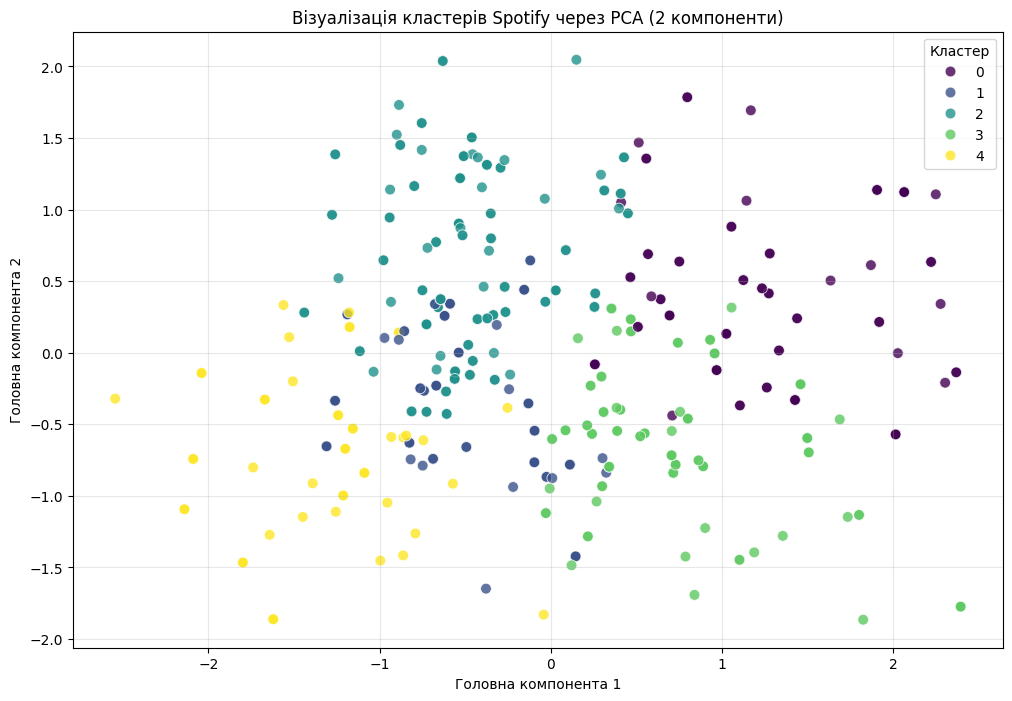

In [41]:
pca2d = PCA(n_components = 2)
pca_data2d = pca.fit_transform(X)


df_popular['pca1_2d'] = pca_data2d[:, 0]
df_popular['pca2_2d'] = pca_data2d[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='pca1', y='pca2', 
    hue='cluster',
    palette='viridis', 
    data=df_popular,
    s=60, alpha=0.8
)

plt.title('Візуалізація кластерів Spotify через PCA (2 компоненти)')
plt.xlabel('Головна компонента 1')
plt.ylabel('Головна компонента 2')
plt.legend(title='Кластер')
plt.grid(True, alpha=0.3)
plt.show()

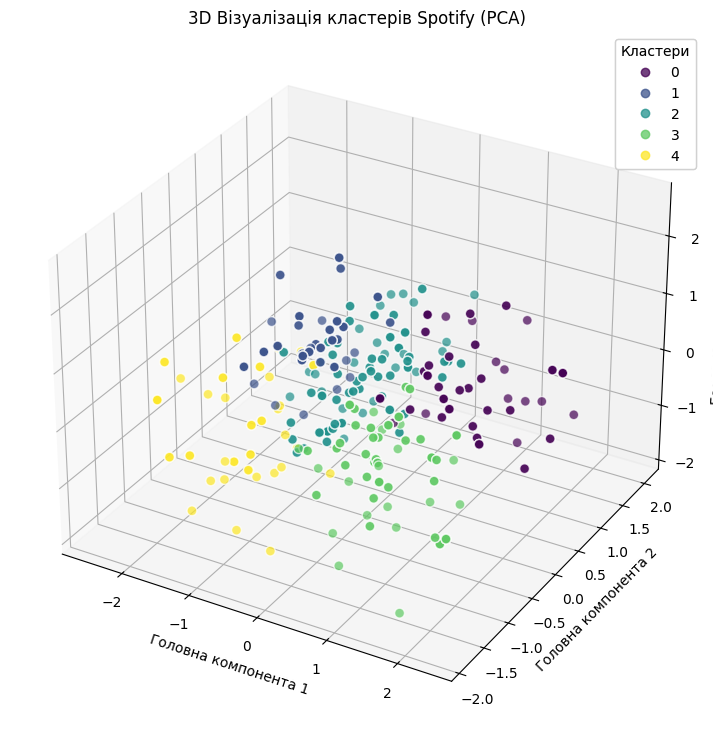

In [44]:
pca_3d = PCA(n_components=3)
pca_results_3d = pca_3d.fit_transform(X)

df_popular['pca1'] = pca_results_3d[:, 0]
df_popular['pca2'] = pca_results_3d[:, 1]
df_popular['pca3'] = pca_results_3d[:, 2]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_popular['pca1'], 
    df_popular['pca2'], 
    df_popular['pca3'], 
    c=df_popular['cluster'], 
    cmap='viridis', 
    s=50, 
    alpha=0.7,
    edgecolors='w'
)

ax.set_title('3D Візуалізація кластерів Spotify (PCA)')
ax.set_xlabel('Головна компонента 1')
ax.set_ylabel('Головна компонента 2')
ax.set_zlabel('Головна компонента 3')

legend = ax.legend(*scatter.legend_elements(), title="Кластери")
ax.add_artist(legend)

plt.show()

<h3>5. Побудова кластеризації</h3>
<ol>
    <li>Для кожного кластера обчислити статистики основних ознак.</li>
    <li>Побудувати таблицю середніх значень основних ознак або графік (heatmap).</li>
    <li>Інтерпретувати кластери, наприклад:
        <ul>
            <li>кластер 0 — енергійні танцювальні треки з високим темпом;</li>
            <li>кластер 1 — спокійні акустичні композиції;</li>
            <li>кластер 2 — експериментальні інструментальні треки тощо.</li>
        </ul>
    </li>
</ol>

Середні значення ознак по кластерах:
         danceability    energy  loudness  speechiness  acousticness  \
cluster                                                                
0            1.047633  0.405745  0.649717     0.228479     -0.762124   
1            1.752557 -0.258686  0.283358     0.506466     -0.547397   
2            0.765494  0.583095  0.816319    -0.169901     -0.447590   
3            0.608311  0.329810  0.621947    -0.198298     -0.565930   
4            0.326237 -0.423615  0.298130     0.100707      0.425490   

         instrumentalness  liveness   valence     tempo  duration_ms  
cluster                                                               
0               -0.484680 -0.244109  0.705272  1.258256    -0.258762  
1               -0.478156 -0.055113 -0.092232 -0.335818    -0.331752  
2               -0.488563 -0.394687  0.460619 -0.519791    -0.338341  
3               -0.482929 -0.062395 -0.556828  0.870198    -0.198100  
4               -0.450808 -0.298

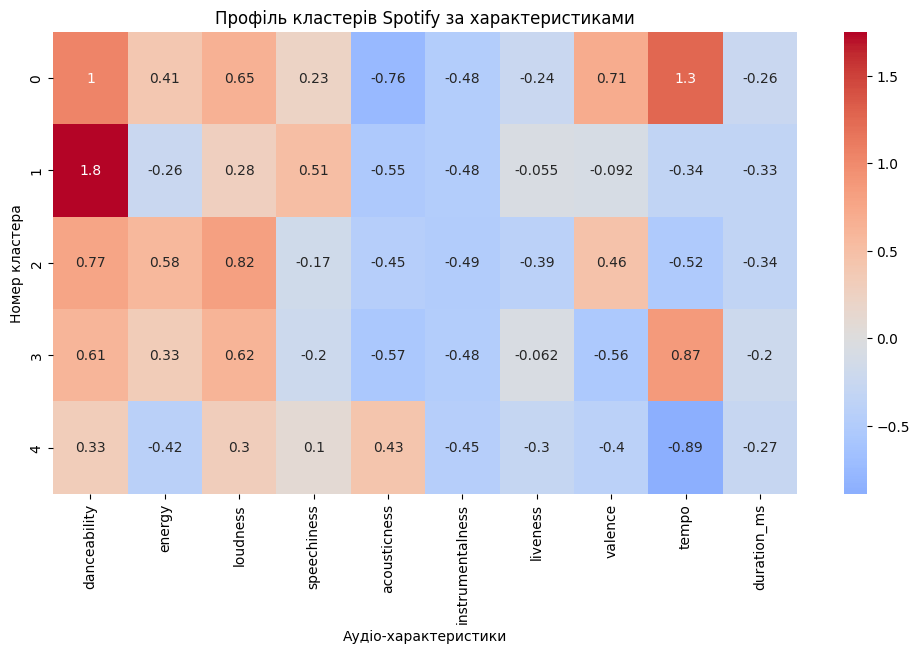

In [45]:
cluster_features = df_popular.groupby('cluster')[colsToScale].mean()

print("Середні значення ознак по кластерах:")
print(cluster_features)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_features, annot=True, cmap='coolwarm', center=0)
plt.title('Профіль кластерів Spotify за характеристиками')
plt.xlabel('Аудіо-характеристики')
plt.ylabel('Номер кластера')
plt.show()

<ul>
    <li>Кластер з високою acousticness та низькою energy - cпокійні акустичні композиції.</li>
    <li>Кластер з високою danceability, energy та loudness - енергійні танцювальні треки.</li>
    <li>Кластер з високою instrumentalness - інструментальна музика.</li>
    <li>Кластер з високою speechiness - реп-композиції.</li>
    <li>Кластер з високою valence - позитивні, життєрадісні пісні</li>
</ul>